In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import scipy
import matplotlib.pyplot as plt

df_orders = pd.read_csv("store_orders.csv")
df_customers = pd.read_csv("store_customers.csv")

con = sqlite3.connect("store.db")
df_orders.to_sql("orders", con, index=False, if_exists="replace")
df_customers.to_sql("customers", con, index=False, if_exists="replace")

40

In [2]:
pd.read_sql("SELECT name FROM sqlite_master", con)

,name
0,orders
1,customers


In [3]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [4]:
pd.read_sql("""
SELECT * FROM orders
WHERE amount > 100
ORDER BY amount DESC
""", con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


In [5]:
pd.read_sql("""
SELECT *, COUNT(*) AS n, AVG(amount) AS average_amount FROM orders
GROUP BY category
ORDER BY average_amount DESC
""", con)

,order_id,customer_id,product,category,amount,order_date,n,average_amount
0,5004,17,monitor,electronics,284.80,2026-05-10,60,190.569500
1,5002,34,shelf,furniture,116.25,2026-06-03,46,146.251522
2,5000,4,paper,office,14.09,2026-05-25,51,30.132549
3,5003,2,granola,snacks,19.72,2026-05-19,43,14.619767


Electronics category earns the most per order according to the aggregated data.

In [6]:
df_orders

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10
...,...,...,...,...,...,...
195,5195,14,chair,furniture,201.59,2026-05-10
196,5196,5,pens,office,39.48,2026-05-09
197,5197,23,monitor,electronics,110.87,2026-06-10
198,5198,12,monitor,electronics,80.15,2026-06-13


In [7]:
df_city = pd.read_sql("""
SELECT city, SUM(amount) AS total_amount FROM orders
JOIN customers ON orders.customer_id = customers.customer_id
GROUP BY city
ORDER BY total_amount DESC
""", con)

In [8]:
df_city

,city,total_amount
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


In [9]:
pd.read_sql("""
SELECT COUNT(*) AS n FROM orders
""", con)

,n
0,200


In [10]:
pd.read_sql("""
SELECT COUNT(*) AS n FROM orders
JOIN customers ON orders.customer_id = customers.customer_id
""", con)

,n
0,195


The Row-Count Audit: Because there are 5 orders with customer_ids that don't match in the customers data, they automatically got deleted once I decided to join the two together. We can also use COUNT(*) and COUNT(customer_id) to find out how many rows are actually missing since COUNT(customer_id) only gives rows that are not NULL.

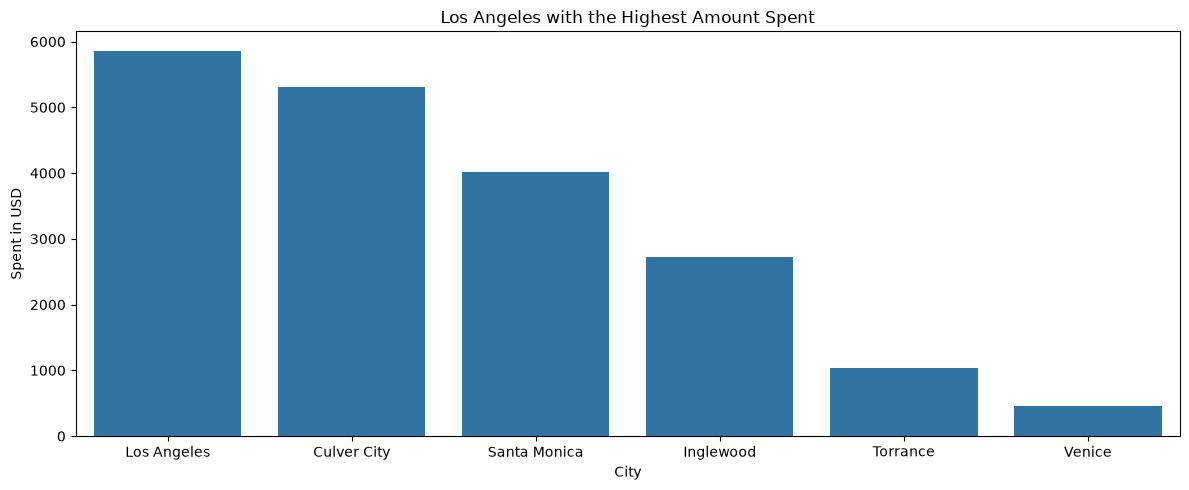

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_city, x="city", y="total_amount", ax=ax)
plt.title("Los Angeles with the Highest Amount Spent")
plt.xlabel("City")
plt.ylabel("Spent in USD")
plt.tight_layout()
plt.show()

Business Question: Which city has the most number of customers?

In [12]:
pd.read_sql("""
SELECT COUNT(*) as n, city FROM customers
GROUP BY city
ORDER BY n DESC
""", con)

,n,city
0,12,Culver City
1,9,Santa Monica
2,9,Los Angeles
3,4,Inglewood
4,3,Venice
5,3,Torrance


Answer: Culver City has the most number of customers.

Because of privacy concerns, I would strip customer names and the cities they live in. Those information could be used internally and privately, but in public space, I wouldn't release them.

Repo Address: https://github.com/yeonghwang-hub/cs82a-portfolio